In [1]:
"""LangGraph Agent"""
import os
from dotenv import load_dotenv
from langgraph.graph import START, StateGraph, MessagesState
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint, HuggingFaceEmbeddings
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.document_loaders import WikipediaLoader
from langchain_community.document_loaders import ArxivLoader
from langchain_community.vectorstores import SupabaseVectorStore
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool
from langchain.tools.retriever import create_retriever_tool
from supabase.client import Client, create_client

In [2]:
load_dotenv()

True

In [3]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers.

    Args:
        a: first int
        b: second int
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Add two numbers.
    
    Args:
        a: first int
        b: second int
    """
    return a + b

@tool
def subtract(a: int, b: int) -> int:
    """Subtract two numbers.
    
    Args:
        a: first int
        b: second int
    """
    return a - b

@tool
def divide(a: int, b: int) -> int:
    """Divide two numbers.
    
    Args:
        a: first int
        b: second int
    """
    if b == 0:
        raise ValueError("Cannot divide by zero.")
    return a / b

@tool
def modulus(a: int, b: int) -> int:
    """Get the modulus of two numbers.
    
    Args:
        a: first int
        b: second int
    """
    return a % b

@tool
def wiki_search(query: str) -> str:
    """Search Wikipedia for a query and return maximum 2 results.
    
    Args:
        query: The search query."""
    search_docs = WikipediaLoader(query=query, load_max_docs=2).load()
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ])
    return {"wiki_results": formatted_search_docs}

@tool
def web_search(query: str) -> str:
    """Search Tavily for a query and return maximum 3 results.
    
    Args:
        query: The search query."""
    search_docs = TavilySearchResults(max_results=3).invoke(query=query)
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ])
    return {"web_results": formatted_search_docs}

@tool
def arvix_search(query: str) -> str:
    """Search Arxiv for a query and return maximum 3 result.
    
    Args:
        query: The search query."""
    search_docs = ArxivLoader(query=query, load_max_docs=3).load()
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content[:1000]}\n</Document>'
            for doc in search_docs
        ])
    return {"arvix_results": formatted_search_docs}


In [4]:
# load the system prompt from the file
with open("system_prompt.txt", "r", encoding="utf-8") as f:
    system_prompt = f.read()

In [5]:
# System message
sys_msg = SystemMessage(content=system_prompt)

In [6]:
sys_msg

SystemMessage(content='You are a helpful assistant tasked with answering questions using a set of tools. \nNow, I will ask you a question. Report your thoughts, and finish your answer with the following template: \nFINAL ANSWER: [YOUR FINAL ANSWER]. \nYOUR FINAL ANSWER should be a number OR as few words as possible OR a comma separated list of numbers and/or strings. If you are asked for a number, don\'t use comma to write your number neither use units such as $ or percent sign unless specified otherwise. If you are asked for a string, don\'t use articles, neither abbreviations (e.g. for cities), and write the digits in plain text unless specified otherwise. If you are asked for a comma separated list, apply the above rules depending of whether the element to be put in the list is a number or a string.\nYour answer should only start with "FINAL ANSWER: ", then follows with the answer. \n', additional_kwargs={}, response_metadata={})

In [ ]:
!pip install sentence-transformers

In [7]:
# build a retriever
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2") #  dim=768

/Users/ron/Documents/github/agentcoursefinal/hf-agent/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
supabase: Client = create_client(
    os.environ.get("SUPABASE_URL"), 
    os.environ.get("SUPABASE_SERVICE_KEY"))

In [9]:
vector_store = SupabaseVectorStore(
    client=supabase,
    embedding= embeddings,
    table_name="documents",
    query_name="match_documents_langchain_2",
)

In [10]:
retriever=vector_store.as_retriever()

In [11]:
create_retriever_tool = create_retriever_tool(
    retriever=vector_store.as_retriever(),
    name="Question Search",
    description="A tool to retrieve similar questions from a vector store.",
)

In [12]:
tools = [
    multiply,
    add,
    subtract,
    divide,
    modulus,
    wiki_search,
    web_search,
    arvix_search,
]

In [13]:
# Build graph function
# Build graph function
def build_graph(provider: str = "huggingface"):
    """Build the graph"""
    # Load environment variables from .env file
    if provider == "google":
        # Google Gemini
        llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)
    elif provider == "groq":
        # Groq https://console.groq.com/docs/models
        llm = ChatGroq(model="qwen-qwq-32b", temperature=0) # optional : qwen-qwq-32b gemma2-9b-it
    elif provider == "huggingface":
        llm = ChatHuggingFace(
            llm=HuggingFaceEndpoint(
                repo_id = "Qwen/Qwen2.5-Coder-32B-Instruct"
            ),
        )
    else:
        raise ValueError("Invalid provider. Choose 'google', 'groq' or 'huggingface'.")
    # Bind tools to LLM
    llm_with_tools = llm.bind_tools(tools)

    # Node
    def assistant(state: MessagesState):
        """Assistant node"""
        return {"messages": [llm_with_tools.invoke(state["messages"])]}
    
    def retriever(state: MessagesState):
        """Retriever node"""
        similar_question = vector_store.similarity_search(state["messages"][0].content)
        example_msg = HumanMessage(
            content=f"Here I provide a similar question and answer for reference: \n\n{similar_question[0].page_content}",
        )
        return {"messages": [sys_msg] + state["messages"] + [example_msg]}

    builder = StateGraph(MessagesState)
    builder.add_node("retriever", retriever)
    builder.add_node("assistant", assistant)
    builder.add_node("tools", ToolNode(tools))
    builder.add_edge(START, "retriever")
    builder.add_edge("retriever", "assistant")
    builder.add_conditional_edges(
        "assistant",
        tools_condition,
    )
    builder.add_edge("tools", "assistant")

    # Compile graph
    return builder.compile()

In [14]:
question = "When was a picture of St. Thomas Aquinas first added to the Wikipedia page on the Principle of double effect?"
# Build the graph
graph = build_graph(provider="huggingface")

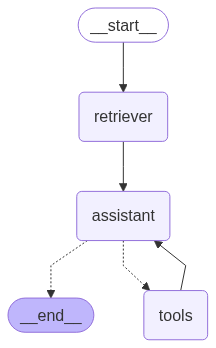

In [15]:
graph

In [16]:
messages = [HumanMessage(content=question)]
messages = graph.invoke({"messages": messages})

In [17]:
for m in messages["messages"]:
        m.pretty_print()

================================ Human Message =================================

When was a picture of St. Thomas Aquinas first added to the Wikipedia page on the Principle of double effect?
================================ System Message ================================

You are a helpful assistant tasked with answering questions using a set of tools. 
Now, I will ask you a question. Report your thoughts, and finish your answer with the following template: 
FINAL ANSWER: [YOUR FINAL ANSWER]. 
YOUR FINAL ANSWER should be a number OR as few words as possible OR a comma separated list of numbers and/or strings. If you are asked for a number, don't use comma to write your number neither use units such as $ or percent sign unless specified otherwise. If you are asked for a string, don't use articles, neither abbreviations (e.g. for cities), and write the digits in plain text unless specified otherwise. If you are asked for a comma separated list, apply the above rules depending of whether